In [1]:
import pandas as pd

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 

In [3]:
df = pd.read_csv("Salary_Data.csv")

In [4]:
df.shape

(30, 2)

In [5]:
df.isna().sum()

YearsExperience    0
Salary             0
dtype: int64

In [6]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [8]:
df = df.drop(columns=['Gender','Education Level','Job Title'], errors='ignore')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [10]:
df = df.dropna(axis=0)

In [11]:
x = df.iloc[:,0:-1]
y = df.iloc[:,-1]

In [12]:
x.shape

(30, 1)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.20, random_state=11)

In [14]:
model = LinearRegression()

In [15]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
y_pred = model.predict(X_test)

In [17]:
import matplotlib.pyplot as plt

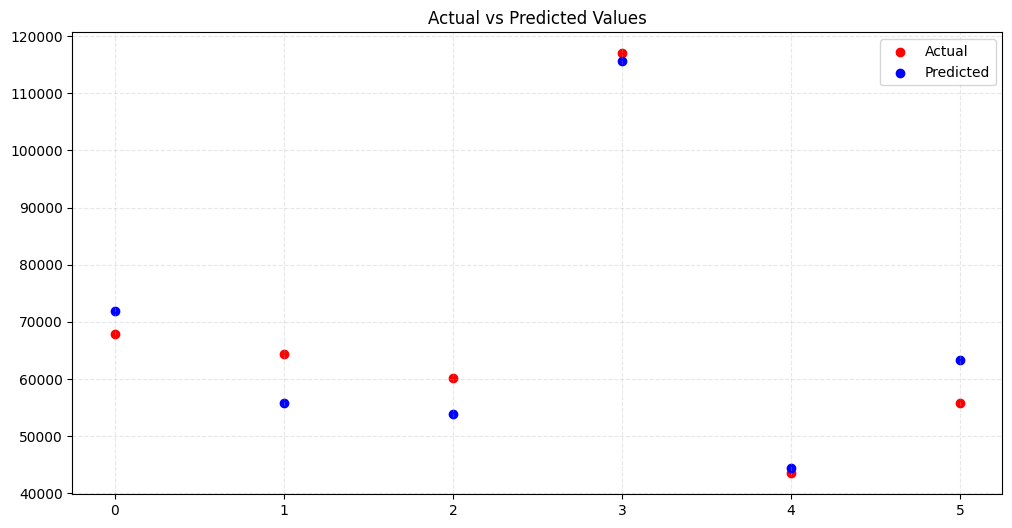

In [18]:
plt.figure(figsize=(12, 6))

plt.scatter(range(len(y_test)), y_test, color='red', label='Actual')
plt.scatter(range(len(y_pred)), y_pred, color='blue', label='Predicted')

plt.title("Actual vs Predicted Values")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

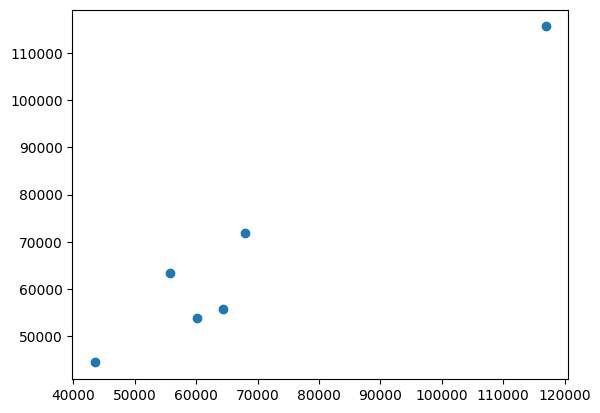

In [19]:
plt.scatter(y_test,y_pred)

In [20]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R2 Score: {r2}")
print(f"Mean Squared Error: {mse}")

R2 Score: 0.940882728477622
Mean Squared Error: 31727520.866778105
